# Base make_moons

O make_moons é uma função da biblioteca scikit-learn usada para gerar um dataset sintético.

Ele cria pontos em formato de "duas luas" (meias-luas entrelaçadas), muito utilizado para testar algoritmos de classificação e clusterização.

Características principais:
- Gera dados bidimensionais (2D), ou seja, cada ponto tem coordenadas (x, y).
- Possui duas classes (normalmente 0 e 1), representando cada "lua".
- Permite adicionar ruído (noise), tornando o problema mais desafiador.
- Os dados NÃO são linearmente separáveis (não dá para separar com uma linha reta).

Por isso, ele é ótimo para mostrar limitações de algoritmos como K-Means e vantagens de outros como DBSCAN ou modelos não lineares.

In [70]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

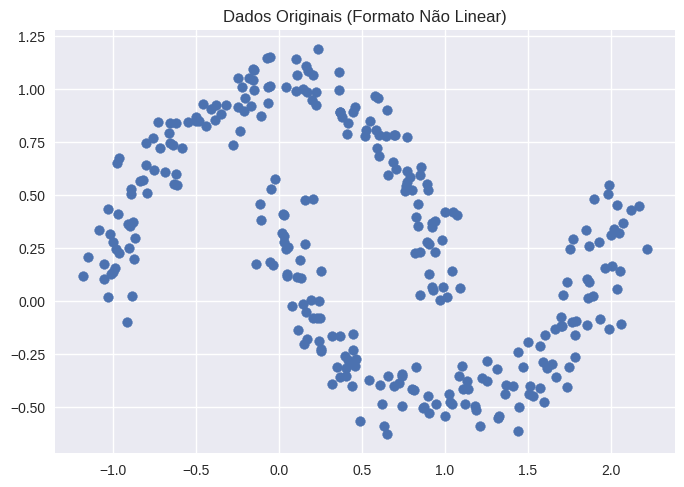

In [71]:
# n_samples=300 → cria 300 pontos no total
# noise=0.08 → adiciona um pequeno ruído aos dados (deixa mais realista e menos perfeito)
# random_state=42 → garante que os dados gerados serão sempre os mesmos (reprodutibilidade)
# X → matriz com as coordenadas dos pontos (formato: [x, y])
# _ → ignora os rótulos (classes), pois aqui queremos apenas visualizar os dados
X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# Cria um gráfico de dispersão (scatter plot)
# X[:, 0] → pega todos os valores da primeira coluna (eixo X)
# X[:, 1] → pega todos os valores da segunda coluna (eixo Y)
# Cada ponto no gráfico representa uma amostra do dataset
plt.scatter(X[:, 0], X[:, 1])
plt.title("Dados Originais (Formato Não Linear)")
plt.show()

In [72]:
#Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#**K-Means**

Aplicamos o **K-Means** porque, ao visualizar os dados, percebemos claramente a presença de dois grupos com formato de "meia-lua". Ou seja, intuitivamente sabemos que existem **2 clusters**.

No entanto, é importante destacar um ponto fundamental:

O **K-Means** assume que os clusters possuem formato mais **circular (ou esférico)**, pois ele agrupa os pontos com base na distância até um centróide.

No caso do `make_moons`, os dados possuem um formato **não linear (curvo)**, semelhante a duas meias-luas entrelaçadas.

Mesmo assim, aplicamos o K-Means com alguns objetivos didáticos:

- Testar como o algoritmo se comporta nesse tipo de dado  
- Evidenciar suas limitações em identificar estruturas não lineares  
- Preparar o terreno para comparação com algoritmos mais adequados  

Isso permite mostrar, na prática, que algoritmos como o **DBSCAN** são mais eficientes nesse cenário, pois conseguem identificar clusters com **formatos arbitrários**.

In [73]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

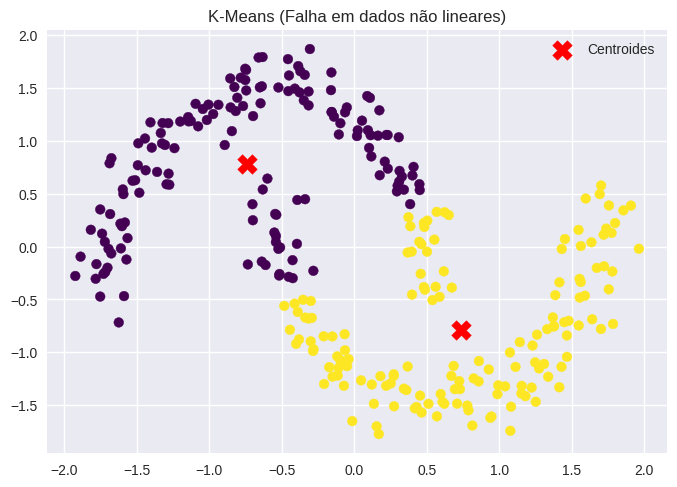

In [74]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap='viridis')

# Centróides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200, label='Centroides')

plt.title("K-Means (Falha em dados não lineares)")
plt.legend()
plt.show()


> O K-Means conseguiu separar corretamente as duas luas?

> Por quê?

## Clusterização Avançada
A **clusterização avançada** faz parte do aprendizado **não supervisionado** e vai além de métodos simples, como o K-Means.

Enquanto algoritmos básicos apenas dividem os dados em grupos mais "simples", técnicas avançadas permitem:

- Identificar **formatos complexos de dados**
- Detectar e lidar com **ruídos (outliers)**
- Descobrir automaticamente **quantos grupos existem**

---

## Algoritmos Baseados em Densidade

Esses algoritmos funcionam de forma diferente dos métodos tradicionais.

Em vez de buscar grupos "redondos", eles procuram **regiões onde há muitos pontos próximos (alta densidade)**.

---

### **DBSCAN**
O **DBSCAN** é um dos principais algoritmos dessa categoria.

Ele:

- Identifica clusters com **qualquer formato** (inclusive não linear)
- Detecta automaticamente pontos isolados (**ruídos**)
- Não precisa definir previamente o número de clusters

Como ele funciona?

- Define um **raio de vizinhança**
- Agrupa pontos que estão próximos uns dos outros
- Pontos muito isolados são classificados como **outliers**

---

## Melhoria e Pré-processamento

Antes de aplicar algoritmos de clusterização, alguns cuidados são importantes.

### Redução de Dimensionalidade

Quando os dados têm muitas variáveis (dimensões), surge um problema chamado:

> "Maldição da dimensionalidade"

Isso acontece porque as distâncias entre os pontos ficam menos significativas.

Para resolver isso, usamos técnicas como:

- **PCA (Principal Component Analysis)**
- **t-SNE**

Essas técnicas reduzem o número de dimensões, mantendo as informações mais importantes.

---

## Métricas de Avaliação

Como não temos rótulos (labels), precisamos de métricas para avaliar a qualidade dos clusters.

### Índice de Silhueta (Silhouette score)

- Mede o quão bem os pontos estão agrupados
- Varia de **-1 a 1**

Interpretação:

- Próximo de **1** → clusters bem definidos  
- Próximo de **0** → clusters sobrepostos  
- Negativo → pontos possivelmente no grupo errado  

---


In [75]:
# Cria um modelo de clusterização usando o algoritmo DBSCAN
# eps=0.3 → define o raio de vizinhança (distância máxima entre pontos para serem considerados vizinhos)
# min_samples=5 → número mínimo de pontos necessários para formar uma região densa (um cluster)
dbscan = DBSCAN(eps=0.3, min_samples=5)

# Aplica o DBSCAN aos dados já normalizados (X_scaled)
# fit_predict() faz duas etapas:
# 1. fit → analisa a densidade dos pontos e identifica regiões densas
# 2. predict → atribui rótulos para cada ponto com base nos clusters encontrados

# labels_dbscan → vetor com o rótulo de cada ponto:
# - Valores como 0, 1, 2... representam clusters diferentes
# - O valor -1 representa pontos considerados ruído (outliers)
labels_dbscan = dbscan.fit_predict(X_scaled)

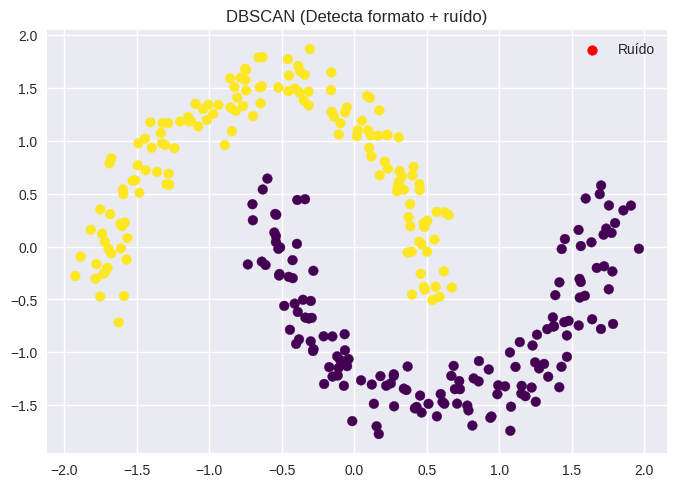

In [76]:
# Cria um gráfico de dispersão dos dados normalizados
# X_scaled[:, 0] → eixo X
# X_scaled[:, 1] → eixo Y
# c=labels_dbscan → colore cada ponto de acordo com o cluster atribuído pelo DBSCAN
# cmap='viridis' → define a paleta de cores para diferenciar os clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap='viridis')

# Identifica os pontos classificados como ruído (outliers)
# No DBSCAN, pontos com rótulo -1 são considerados ruído
# se labels_dbscan == -1 ele adiciona no noise
noise = labels_dbscan == -1

# Plota novamente apenas os pontos de ruído
# Eles são destacados em vermelho para facilitar a visualização
# label='Ruído' → adiciona uma legenda para esses pontos
plt.scatter(X_scaled[noise, 0], X_scaled[noise, 1], color='red', label='Ruído')

plt.title("DBSCAN (Detecta formato + ruído)")
plt.legend()
plt.show()

In [77]:
# np.unique faz duas coisas:
# 1. unique → retorna os valores únicos presentes em labels_dbscan (ex: -1, 0, 1, ...)
# 2. counts → retorna quantas vezes cada valor aparece
# Ou seja, estamos contando quantos pontos existem em cada cluster
unique, counts = np.unique(labels_dbscan, return_counts=True)

# Percorre simultaneamente os rótulos (unique) e suas quantidades (counts)
for label, count in zip(unique, counts):
    if label == -1:
        # Se o rótulo for -1, significa que são pontos considerados ruído pelo DBSCAN
        print(f"Ruído: {count} pontos")
    else:
        # Caso contrário, são clusters válidos
        # label → número do cluster
        # count → quantidade de pontos naquele cluster
        print(f"Cluster {label}: {count} pontos")

Cluster 0: 150 pontos
Cluster 1: 150 pontos


# **Redução de Dimensionalidade**

A **redução de dimensionalidade** é uma técnica de **aprendizado não supervisionado** que tem como objetivo transformar um conjunto de dados com muitas variáveis (**alta dimensão**) em uma representação com menos variáveis, preservando o máximo possível da **informação relevante**.

Essa técnica é fundamental em Machine Learning para:

- Melhorar o desempenho dos modelos  
- Reduzir custo computacional  
- Facilitar a visualização e interpretação dos dados  

---

## A Maldição da Dimensionalidade

Quando o número de variáveis (**features**) cresce, o espaço de dados aumenta **exponencialmente**.

Isso gera problemas de:

### Overfitting (Sobreajuste)
- Com dados muito espalhados (esparsos), o modelo pode aprender padrões do **ruído**
- Resultado: baixa capacidade de **generalização**

### Uniformidade de Distâncias
- Em altas dimensões, as distâncias entre os pontos ficam muito parecidas
- Isso prejudica algoritmos baseados em distância, como:
  - KNN  
  - K-Means  
  - DBSCAN  
---

## Por que usar Redução de Dimensionalidade?

### Eficiência Computacional
- Menos variáveis → menor tempo de processamento  
- Reduz uso de memória  

### Visualização de Dados
- Permite transformar dados em **2D ou 3D**
- Facilita identificar:
  - Clusters  
  - Padrões  
  - Outliers  

### Redução de Ruído
- Remove variáveis pouco relevantes  
- Mantém apenas o que realmente importa  

### Interpretabilidade
- Modelos com menos variáveis são mais fáceis de entender  

---

## PCA (Principal Component Analysis)

- Técnica **não supervisionada**
- Cria novos eixos chamados **Componentes Principais (PCs)**
- Esses eixos capturam a **maior variância dos dados**

Ideia principal:
> Manter o máximo de informação com o menor número de dimensões

- O **1º componente** contém a maior variância  
- O **2º componente** contém a segunda maior, e assim por diante  

---
A redução de dimensionalidade é extremamente útil, mas exige cuidado:

- Pode haver **perda de informação**
- Novas variáveis podem ser mais difíceis de interpretar  
- Primeiro, treine o modelo com os dados originais  
- Depois, aplique redução se:
  - O modelo estiver lento  
  - Ou para análise exploratória (EDA)


In [78]:
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

In [79]:
# Gera um dataset sintético usando a função make_blobs (scikit-learn)
# Esse tipo de dataset é muito usado para testar algoritmos de clusterização
# X_high → matriz com os dados gerados (300 linhas × 5 colunas)
# _ → ignora os rótulos verdadeiros (clusters reais), pois não usaremos aqui
X_high, _ = make_blobs(
    n_samples=300,
    centers=4,
    n_features=5,
    # cluster_std=1.5 → controla o espalhamento dos pontos em cada cluster
    # Quanto maior o valor, mais "espalhados" e sobrepostos os clusters ficam
    # Isso torna o problema mais difícil para os algoritmos
    cluster_std=1.5,
    random_state=42
)

In [80]:
#Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_high)

In [81]:
dbscan_high = DBSCAN(eps=0.9, min_samples=5)
labels_high = dbscan_high.fit_predict(X_scaled)

In [82]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [83]:
dbscan_pca = DBSCAN(eps=0.5, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

In [84]:
def mostrar_clusters(labels, titulo):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{titulo} ")
    for label, count in zip(unique, counts):
        if label == -1:
            print(f"Ruído: {count} pontos")
        else:
            print(f"Cluster {label}: {count} pontos")

mostrar_clusters(labels_high, "DBSCAN em 5D (ANTES do PCA)")
mostrar_clusters(labels_pca, "DBSCAN em 2D (DEPOIS do PCA)")


DBSCAN em 5D (ANTES do PCA) 
Ruído: 4 pontos
Cluster 0: 74 pontos
Cluster 1: 74 pontos
Cluster 2: 75 pontos
Cluster 3: 73 pontos

DBSCAN em 2D (DEPOIS do PCA) 
Ruído: 3 pontos
Cluster 0: 147 pontos
Cluster 1: 75 pontos
Cluster 2: 75 pontos


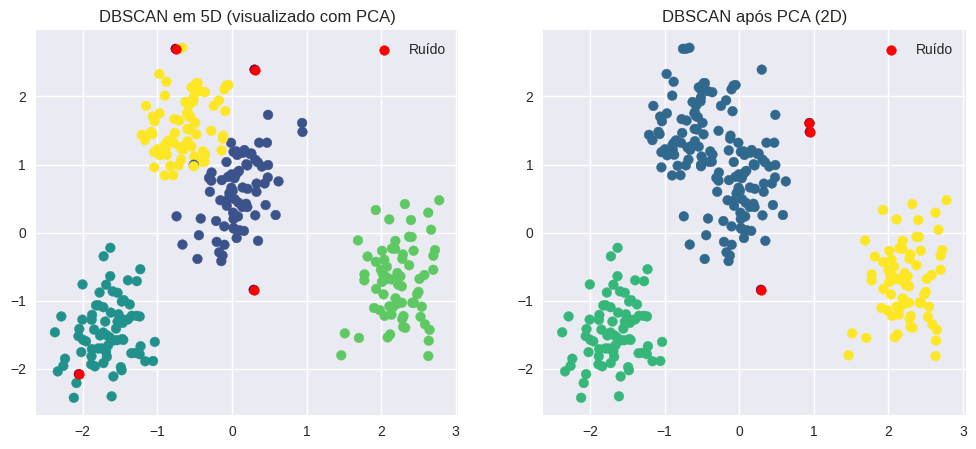

In [85]:
plt.figure(figsize=(12, 5))

# DBSCAN em 5D (visualizado com PCA)
# (1, 2, 1) significa:
# 1 linha de gráficos
# 2 colunas de gráficos
# posição 1 → estamos desenhando no primeiro gráfico (à esquerda)
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_high, cmap='viridis')

noise = labels_high == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1], color='red', label='Ruído')

plt.title("DBSCAN em 5D (visualizado com PCA)")
plt.legend()

# DBSCAN em 2D
# (1, 2, 2) significa:
# 1 linha de gráficos
# 2 colunas de gráficos
# posição 2 → estamos desenhando no segundo gráfico (à direita)
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis')

noise = labels_pca == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1], color='red', label='Ruído')

plt.title("DBSCAN após PCA (2D)")
plt.legend()

plt.show()